# 🍼 Class 05 — Child Nutrition Survey Dataset: Label Encoding

## 📌 ভূমিকা (Introduction)

এই নোটবুকে আমরা একটি **Child Nutrition Survey Dataset** নিয়ে কাজ করব। এটি একটি Real-world Survey Data — যেখানে মানুষের কাছ থেকে শিশুর পুষ্টি সম্পর্কিত বিভিন্ন প্রশ্নের উত্তর সংগ্রহ করা হয়েছে।

### আমাদের লক্ষ্য (Our Task):
- Dataset লোড ও Explore করা
- অপ্রয়োজনীয় Column (`Timestamp`, `Name`) মুছে ফেলা
- **Label Encoding** দিয়ে সব Categorical (Text) Column কে Numerical এ রূপান্তর করা — যাতে ML Model বুঝতে পারে

---

### 🧠 Label Encoding কী এবং কেন?

ML Model শুধু **সংখ্যা (Number)** বোঝে — Text বোঝে না। কিন্তু Survey Data-তে উত্তর থাকে Text আকারে, যেমন:
- "Male" / "Female"
- "Yes" / "No"
- "Agree" / "Disagree" / "Neutral"

**Label Encoding** এই Text উত্তরগুলোকে সংখ্যায় রূপান্তর করে:

| Text | Encoded Number |
|---|---|
| Female | 0 |
| Male | 1 |
| Yes | 1 |
| No | 0 |

> 💡 Label Encoder প্রতিটি Unique মানকে **Alphabetical Order** অনুযায়ী 0, 1, 2, 3... সংখ্যা দেয়।

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 📂 Dataset লোড করা

Survey থেকে সংগৃহীত CSV ফাইল লোড করা হচ্ছে। এই Dataset-এ প্রতিটি Row একজন Respondent-এর উত্তর এবং প্রতিটি Column একটি প্রশ্ন।

> ⚠️ **সাধারণ ভুল:** Colab-এ `/content/` path সঠিক, কিন্তু ফাইল আগে আপলোড না করলে `FileNotFoundError` আসবে।

In [2]:
dataset=pd.read_csv('/content/data.csv')

## 👀 সম্পূর্ণ Dataset দেখা

Dataset-এর সব Row ও Column দেখা হচ্ছে — এতে ডেটার প্রকৃতি ও পরিসর সম্পর্কে প্রাথমিক ধারণা তৈরি হবে।

In [3]:
dataset

,Timestamp,What is your name?,What is your age?,What is your gender?,A child should sleep?,"At what ages do food allergies, iron deficiency and occur in children?",During the early growing stage of a child the cause of malnutrition according to you is-,Child nutrition can also effect by,During puberty most of the child need to take proper amount of nutrients because,The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be,A girl child needs to have best care during puberty,The most common malnutrition of children in our country,Do you prefer parental awareness in case of a sound health of a child,Nutrition of a child related to,Diarrhea is a very common disease of infant. According to you it happens due to,Some people think that feeding a child more and more Can increase their body growth. But according to you it is a,"Whole grain foods such as breads, cereals that are high in Fibre",Toddlers & preschoolers should have following nutrients in their diet
0,12/24/2022 15:02:36,Ayesha Siraji Shejuty,21,Female,8 to 9 hrs,3 to 6 year,Poverty,Quantity of intake food,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
1,12/24/2022 15:08:21,Nushrah Ipshita,18,Female,8 to 9 hrs,3 to 6 year,Poverty,Environment,They have started to growing,Malnutrition,Due to her mental health,Marasmus,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
2,12/24/2022 15:09:34,Nabhan Ezaz Ilhan,18,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Family care,The growth rate is massive in this period,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Marasmus,Strongly agree,"Including vegetables, fruits",Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
3,12/24/2022 17:38:50,Rashedul Hoque Robin,23,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,Due to her mental health,Rickets,Agree,"Including vegetables, fruits",Unhealthy environment,Overweight,Helps bone growth,Calcium for bone growth
4,12/24/2022 17:50:51,Mubashira Hoque,22,Female,9 to 10 hrs,3 to 6 year,Poverty,Family care,They have started to growing,Malnutrition,Physiological change,Rickets,Agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Making stool,Calcium for bone growth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,1/1/2023 22:10:57,Nila rahman,19,Female,8 to 9 hrs,3 to 6 year,Poverty,Physical well-being,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Helps bone growth,Calcium for bone growth
407,1/1/2023 22:11:29,Abayat Rahman,21,Male,8 to 9 hrs,1 to 3 year,Poverty,Family care,They have started to growing,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Helps bone growth,Calcium for bone growth
408,1/1/2023 22:12:13,Talha Ahmed,23,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Calcium for bone growth
409,1/1/2023 22:12:49,Latifur Rahman,21,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,A

## ❓ Null Value চেক করা

**To check Null Value** ✅

Survey Data-তে প্রায়ই কিছু মানুষ কিছু প্রশ্নের উত্তর না দিয়ে বাদ দিয়ে যায় — ফলে Null Value তৈরি হয়। ML Model-এ দেওয়ার আগে এগুলো Handle করতে হয়।

> 💡 যদি কোনো Column-এ Null থাকে, পরবর্তীতে `fillna()` বা `dropna()` দিয়ে সেটা Handle করতে হবে।

In [4]:
dataset.isnull().sum()

,0
Timestamp,0
What is your name?,0
What is your age?,0
What is your gender?,0
A child should sleep?,0
"At what ages do food allergies, iron deficiency and occur in children?",0
During the early growing stage of a child the cause of malnutrition according to you is-,0
Child nutrition can also effect by,0
During puberty most of the child need to take proper amount of nutrients because,0
The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be,0


## 👥 Gender Column বিশ্লেষণ

**Male koyta ar Female koyta ta bole dibe** ✅

`value_counts()` প্রতিটি Unique মান কতবার আছে তা গণনা করে দেখায়। এখানে Survey-তে কতজন Male ও কতজন Female উত্তর দিয়েছে তা জানা যাবে।

এরপর `hist()` দিয়ে সেটার একটি Histogram Plot তৈরি করা হচ্ছে — Visual আকারে Gender Distribution দেখতে।

In [6]:
dataset["What is your gender?"].value_counts()

,count
What is your gender?,
Male,207
Female,204


<Axes: >

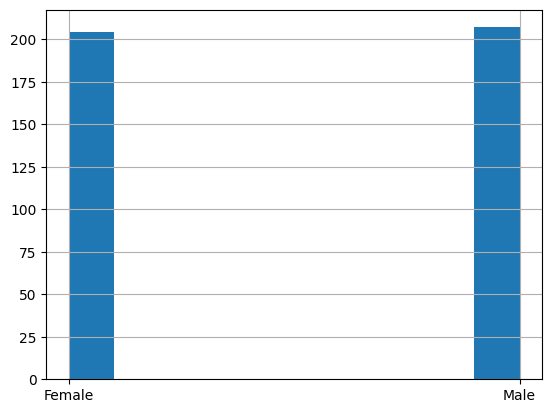

In [9]:
dataset["What is your gender?"].hist()

## 🗑️ অপ্রয়োজনীয় Column Drop করা — `Timestamp`

`Timestamp` Column টি শুধু Survey জমা দেওয়ার সময় রেকর্ড করে — এটি ML Model Training-এ কোনো কাজে আসে না, তাই বাদ দেওয়া হচ্ছে।

### `drop()` এর Parameter ব্যাখ্যা:

| Parameter | মান | অর্থ |
|---|---|---|
| Column নাম | `"Timestamp"` | কোন Column মুছবো |
| `axis` | `1` | Column মুছবো (0 হলে Row মুছতো) |
| `inplace` | `True` | Original DataFrame-এই পরিবর্তন করো |

### `inplace=True` কেন জরুরি?

**inplace=True মানে হলো — পরিবর্তনটা সরাসরি original dataframe এ করে ফেলো, আলাদা কোনো copy বানিয়ো না।** ✅

| | Code | ফলাফল |
|---|---|---|
| `inplace=True` দিলে | `dataset.drop("Timestamp", axis=1, inplace=True)` | `dataset` নিজেই বদলে যাবে |
| `inplace=True` না দিলে | `dataset.drop("Timestamp", axis=1)` | `dataset` অপরিবর্তিত থাকবে, নতুন DataFrame return হবে |
| বিকল্প পদ্ধতি | `dataset = dataset.drop("Timestamp", axis=1)` | Return হওয়া DataFrame কে আবার assign করতে হবে |

> ⚠️ **সবচেয়ে সাধারণ ভুল:** `inplace=True` না দিয়ে শুধু `dataset.drop(...)` লিখলে মনে হয় কাজ হয়েছে, কিন্তু `dataset` প্রিন্ট করলে দেখা যাবে Column এখনো আছে!

In [10]:
# dataset.drop("Timestamp")
# eikhane timestamp ke row onujai khuja hoy.Tohn axis er man 0 thake .but eita ase row onujai. tai axis=1 hbe. but tateo hbe na. implace true lagbe
dataset.drop("Timestamp",axis=1,inplace=True)

In [11]:
dataset

,What is your name?,What is your age?,What is your gender?,A child should sleep?,"At what ages do food allergies, iron deficiency and occur in children?",During the early growing stage of a child the cause of malnutrition according to you is-,Child nutrition can also effect by,During puberty most of the child need to take proper amount of nutrients because,The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be,A girl child needs to have best care during puberty,The most common malnutrition of children in our country,Do you prefer parental awareness in case of a sound health of a child,Nutrition of a child related to,Diarrhea is a very common disease of infant. According to you it happens due to,Some people think that feeding a child more and more Can increase their body growth. But according to you it is a,"Whole grain foods such as breads, cereals that are high in Fibre",Toddlers & preschoolers should have following nutrients in their diet
0,Ayesha Siraji Shejuty,21,Female,8 to 9 hrs,3 to 6 year,Poverty,Quantity of intake food,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
1,Nushrah Ipshita,18,Female,8 to 9 hrs,3 to 6 year,Poverty,Environment,They have started to growing,Malnutrition,Due to her mental health,Marasmus,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
2,Nabhan Ezaz Ilhan,18,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Family care,The growth rate is massive in this period,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Marasmus,Strongly agree,"Including vegetables, fruits",Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
3,Rashedul Hoque Robin,23,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,Due to her mental health,Rickets,Agree,"Including vegetables, fruits",Unhealthy environment,Overweight,Helps bone growth,Calcium for bone growth
4,Mubashira Hoque,22,Female,9 to 10 hrs,3 to 6 year,Poverty,Family care,They have started to growing,Malnutrition,Physiological change,Rickets,Agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Making stool,Calcium for bone growth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,Nila rahman,19,Female,8 to 9 hrs,3 to 6 year,Poverty,Physical well-being,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Helps bone growth,Calcium for bone growth
407,Abayat Rahman,21,Male,8 to 9 hrs,1 to 3 year,Poverty,Family care,They have started to growing,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Helps bone growth,Calcium for bone growth
408,Talha Ahmed,23,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Calcium for bone growth
409,Latifur Rahman,21,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Kwashiorkor,Strongly agree,Milk as a supplement,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Calcium for bone growt

## 🗑️ `Name` Column Drop করা

`What is your name?` Column টিও ML Model-এ কোনো কাজে আসে না — প্রতিটি মানুষের নাম Unique, তাই এটি কোনো Pattern শেখাতে পারে না। বাদ দেওয়া হচ্ছে।

In [12]:
dataset.drop("What is your name?", axis=1, inplace=True)

dataset

,What is your age?,What is your gender?,A child should sleep?,"At what ages do food allergies, iron deficiency and occur in children?",During the early growing stage of a child the cause of malnutrition according to you is-,Child nutrition can also effect by,During puberty most of the child need to take proper amount of nutrients because,The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be,A girl child needs to have best care during puberty,The most common malnutrition of children in our country,Do you prefer parental awareness in case of a sound health of a child,Nutrition of a child related to,Diarrhea is a very common disease of infant. According to you it happens due to,Some people think that feeding a child more and more Can increase their body growth. But according to you it is a,"Whole grain foods such as breads, cereals that are high in Fibre",Toddlers & preschoolers should have following nutrients in their diet
0,21,Female,8 to 9 hrs,3 to 6 year,Poverty,Quantity of intake food,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
1,18,Female,8 to 9 hrs,3 to 6 year,Poverty,Environment,They have started to growing,Malnutrition,Due to her mental health,Marasmus,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
2,18,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Family care,The growth rate is massive in this period,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Marasmus,Strongly agree,"Including vegetables, fruits",Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
3,23,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,Due to her mental health,Rickets,Agree,"Including vegetables, fruits",Unhealthy environment,Overweight,Helps bone growth,Calcium for bone growth
4,22,Female,9 to 10 hrs,3 to 6 year,Poverty,Family care,They have started to growing,Malnutrition,Physiological change,Rickets,Agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Making stool,Calcium for bone growth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,19,Female,8 to 9 hrs,3 to 6 year,Poverty,Physical well-being,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Helps bone growth,Calcium for bone growth
407,21,Male,8 to 9 hrs,1 to 3 year,Poverty,Family care,They have started to growing,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Helps bone growth,Calcium for bone growth
408,23,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Calcium for bone growth
409,21,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Kwashiorkor,Strongly agree,Milk as a supplement,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Calcium for bone growth


# 🔢 Label Encoding — Text কে Number এ রূপান্তর

## 🧠 বিস্তারিত থিওরি

**Doing Label Encoding** ✅

**Label Encoding** হলো Categorical Data (Text) কে Numerical Data (সংখ্যা) তে রূপান্তরের পদ্ধতি।

### কেন Numerical হওয়া দরকার?
ML Algorithms গণিতের উপর ভিত্তি করে কাজ করে — Addition, Multiplication, Distance Calculation ইত্যাদি। এগুলো Text দিয়ে সম্ভব নয়, তাই সব Text মানকে Number এ বদলাতে হয়।

### Label Encoding কীভাবে কাজ করে?
["Female", "Male", "Male", "Female"]

→ Alphabetical Sort: Female=0, Male=1

→ [0, 1, 1, 0]

### `fit_transform()` এর দুটি কাজ:

| ধাপ | কাজ |
|---|---|
| `fit()` | Column-এর সব Unique মান দেখে এবং প্রতিটিকে একটি সংখ্যা assign করে |
| `transform()` | সেই সংখ্যা অনুযায়ী পুরো Column-কে রূপান্তর করে |

> ⚠️ **Label Encoding-এর সীমাবদ্ধতা:** Label Encoding এমন একটি সমস্যা তৈরি করতে পারে যেখানে Model মনে করে বড় সংখ্যা = বেশি গুরুত্বপূর্ণ। যেমন `2 > 1 > 0` — কিন্তু "Agree", "Disagree", "Neutral" এর মধ্যে কোনো Ranking নেই। এই সমস্যার সমাধান হলো **One-Hot Encoding** (পরের Class-এ শেখা হবে)।

> ✅ **কখন Label Encoding ঠিক আছে?** যখন Column-এ Natural Order থাকে — যেমন: Low=0, Medium=1, High=2।

In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

## 👤 Gender Column — Label Encoding

**Gender column** ✅

`le.fit_transform()` দিয়ে `"What is your gender?"` Column-এর Text মানগুলো (Male/Female) সংখ্যায় রূপান্তর করা হচ্ছে এবং সরাসরি সেই Column-এই লিখে দেওয়া


In [15]:
dataset["What is your gender?"]=le.fit_transform(dataset["What is your gender?"])
dataset["What is your gender?"]

,What is your gender?
0,0
1,0
2,1
3,1
4,0
...,...
406,0
407,1
408,1
409,1


## 😴 Sleep Column — Label Encoding

**A child should sleep?** ✅

শিশুর ঘুমের সময় সংক্রান্ত প্রশ্নের উত্তর Encode করা হচ্ছে।

In [16]:
dataset["A child should sleep?"] = le.fit_transform(dataset["A child should sleep?"])
dataset["A child should sleep?"]

,A child should sleep?
0,1
1,1
2,1
3,1
4,2
...,...
406,1
407,1
408,1
409,1


## 🤧 Food Allergy Column — Label Encoding

**At what ages do food allergies, iron deficiency and occur in children?** ✅

শিশুদের খাদ্য অ্যালার্জি ও আয়রনের ঘাটতি সংক্রান্ত প্রশ্নের উত্তর Encode করা হচ্ছে।

In [17]:
dataset["At what ages do food allergies, iron deficiency and occur in children?"] = le.fit_transform(dataset["At what ages do food allergies, iron deficiency and occur in children?"])
dataset["At what ages do food allergies, iron deficiency and occur in children?"]



,"At what ages do food allergies, iron deficiency and occur in children?"
0,1
1,1
2,1
3,1
4,1
...,...
406,1
407,0
408,0
409,0


## 🥗 Malnutrition Cause Column — Label Encoding

**During the early growing stage of a child the cause of malnutrition according to you is-** ✅

শিশুর বিকাশকালীন সময়ে অপুষ্টির কারণ সংক্রান্ত মতামত Encode করা হচ্ছে।

In [18]:
dataset["During the early growing stage of a child the cause of malnutrition according to you is-"] = le.fit_transform(dataset["During the early growing stage of a child the cause of malnutrition according to you is-"])
dataset["During the early growing stage of a child the cause of malnutrition according to you is-"]

,During the early growing stage of a child the cause of malnutrition according to you is-
0,2
1,2
2,0
3,0
4,2
...,...
406,2
407,2
408,0
409,0


## 🌍 Child Nutrition Effect Column — Label Encoding

**Child nutrition can also effect by** ✅

কী কী বিষয় শিশুর পুষ্টিকে প্রভাবিত করে — সেই উত্তর Encode করা হচ্ছে।

In [19]:
dataset["Child nutrition can also effect by"] = le.fit_transform(dataset["Child nutrition can also effect by"])
dataset["Child nutrition can also effect by"]

,Child nutrition can also effect by
0,3
1,0
2,1
3,0
4,1
...,...
406,2
407,1
408,0
409,0


## 🌱 Puberty Nutrients Column — Label Encoding

**During puberty most of the child need to take proper amount of nutrients because** ✅

বয়ঃসন্ধিকালে সঠিক পুষ্টির প্রয়োজনীয়তা সম্পর্কিত উত্তর Encode করা হচ্ছে।

In [20]:
dataset["During puberty most of the child need to take proper amount of nutrients because"] = le.fit_transform(dataset["During puberty most of the child need to take proper amount of nutrients because"])
dataset["During puberty most of the child need to take proper amount of nutrients because"]

,During puberty most of the child need to take proper amount of nutrients because
0,2
1,2
2,1
3,2
4,2
...,...
406,2
407,2
408,2
409,2


## 🤱 Breastfeeding Column — Label Encoding

**The most important nutrition source of an infant or baby is breast feeding...** ✅

বুকের দুধ খাওয়ানো সংক্রান্ত মতামত Encode করা হচ্ছে।

In [21]:
dataset["The most important nutrition source of  an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be"] = le.fit_transform(dataset["The most important nutrition source of  an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be"])
dataset["The most important nutrition source of  an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be"]

,The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be
0,0
1,0
2,1
3,1
4,0
...,...
406,0
407,1
408,0
409,1


## 👧 Girl Child Puberty Column — Label Encoding

**A girl child needs to have best care during puberty** ✅

মেয়ে শিশুর বয়ঃসন্ধিকালীন যত্ন সংক্রান্ত উত্তর Encode করা হচ্ছে।

In [22]:
dataset["A girl child needs to have best care during puberty"] = le.fit_transform(dataset["A girl child needs to have best care during puberty"])
dataset["A girl child needs to have best care during puberty"]

,A girl child needs to have best care during puberty
0,1
1,1
2,0
3,1
4,2
...,...
406,1
407,0
408,1
409,0


## 🇧🇩 Common Malnutrition Column — Label Encoding

**The most common malnutrition of children in our country** ✅

আমাদের দেশে শিশুদের সবচেয়ে সাধারণ অপুষ্টির ধরন সম্পর্কিত উত্তর Encode করা হচ্ছে।

In [23]:
dataset["The most common malnutrition of children in our country"] = le.fit_transform(dataset["The most common malnutrition of children in our country"])
dataset["The most common malnutrition of children in our country"]

,The most common malnutrition of children in our country
0,2
1,1
2,1
3,2
4,2
...,...
406,2
407,2
408,2
409,0


## 👨‍👩‍👧 Parental Awareness Column — Label Encoding

**Do you prefer parental awareness in case of a sound health of a child** ✅

শিশুর সুস্বাস্থ্যের জন্য অভিভাবকের সচেতনতার গুরুত্ব সম্পর্কিত উত্তর Encode করা হচ্ছে।

In [24]:
dataset["Do you prefer parental awareness in case of a sound health of a child"] = le.fit_transform(dataset["Do you prefer parental awareness in case of a sound health of a child"])
dataset["Do you prefer parental awareness in case of a sound health of a child"]

,Do you prefer parental awareness in case of a sound health of a child
0,2
1,2
2,2
3,0
4,0
...,...
406,2
407,2
408,2
409,2


## 🔗 Nutrition Related Column — Label Encoding

**Nutrition of a child related to** ✅

শিশুর পুষ্টি কী কী বিষয়ের সাথে সম্পর্কিত — সেই উত্তর Encode করা হচ্ছে।

In [25]:
dataset["Nutrition of a child related to"] = le.fit_transform(dataset["Nutrition of a child related to"])
dataset["Nutrition of a child related to"]

,Nutrition of a child related to
0,2
1,2
2,0
3,0
4,2
...,...
406,2
407,2
408,2
409,1


## 🦠 Diarrhea Column — Label Encoding

**Diarrhea is a very common disease of infant. According to you it happens due to** ✅

শিশুদের ডায়রিয়ার কারণ সম্পর্কিত মতামত Encode করা হচ্ছে।

In [26]:
dataset["Diarrhea is a very common disease of infant. According to you it happens due to"] = le.fit_transform(dataset["Diarrhea is a very common disease of infant. According to you it happens due to"])
dataset["Diarrhea is a very common disease of infant. According to you it happens due to"]

,Diarrhea is a very common disease of infant. According to you it happens due to
0,0
1,2
2,0
3,2
4,0
...,...
406,2
407,0
408,0
409,0


## 🍔 Overfeeding Column — Label Encoding

**Some people think that feeding a child more and more Can increase their body growth. But according to you it is a** ✅

অতিরিক্ত খাওয়ানো শিশুর বৃদ্ধিতে সাহায্য করে কিনা — সেই মতামত Encode করা হচ্ছে।

In [27]:
dataset["Some people think that feeding a child more and more Can increase their body growth. But according to you it is a"] = le.fit_transform(dataset["Some people think that feeding a child more and more Can increase their body growth. But according to you it is a"])
dataset["Some people think that feeding a child more and more Can increase their body growth. But according to you it is a"]

,Some people think that feeding a child more and more Can increase their body growth. But according to you it is a
0,0
1,0
2,0
3,2
4,2
...,...
406,0
407,2
408,0
409,0


## 🌾 Whole Grain Column — Label Encoding

**Whole grain foods such as breads, cereals that are high in Fibre** ✅

আঁশযুক্ত শস্যজাতীয় খাবার সম্পর্কিত উত্তর Encode করা হচ্ছে।

In [28]:
dataset["Whole grain foods such as breads, cereals that are high in Fibre"] = le.fit_transform(dataset["Whole grain foods such as breads, cereals that are high in Fibre"])
dataset["Whole grain foods such as breads, cereals that are high in Fibre"]

,"Whole grain foods such as breads, cereals that are high in Fibre"
0,3
1,3
2,3
3,0
4,3
...,...
406,0
407,0
408,3
409,3


## 🥦 Toddlers Nutrients Column — Label Encoding

**Toddlers & preschoolers should have following nutrients in their diet** ✅

ছোট শিশুদের (Toddler ও Preschooler) খাদ্যতালিকায় কোন কোন পুষ্টি থাকা দরকার — সেই মতামত Encode করা হচ্ছে।

In [29]:
dataset["Toddlers & preschoolers should have following nutrients in their diet"] = le.fit_transform(dataset["Toddlers & preschoolers should have following nutrients in their diet"])
dataset["Toddlers & preschoolers should have following nutrients in their diet"]

,Toddlers & preschoolers should have following nutrients in their diet
0,1
1,1
2,1
3,0
4,0
...,...
406,0
407,0
408,0
409,0


## ✅ Final Dataset দেখা — সব Encoding সম্পন্ন

`head(20)` দিয়ে প্রথম ২০টি Row দেখা হচ্ছে — এখন সব Column-এ Text-এর বদলে **সংখ্যা** দেখা যাবে। Dataset এখন ML Model-এ দেওয়ার জন্য প্রস্তুত।

---

# 🏁 চূড়ান্ত সারসংক্ষেপ (Final Summary)

| বিষয় | কী শিখলাম |
|---|---|
| **`value_counts()`** | প্রতিটি Unique মান কতবার আছে গণনা করে |
| **`drop(axis=1)`** | Column মুছে ফেলা |
| **`inplace=True`** | Original DataFrame-এই পরিবর্তন সংরক্ষণ |
| **`LabelEncoder`** | Text → Number রূপান্তর |
| **`fit_transform()`** | Unique মান শিখে একসাথে Encode করে |
| **Label Encoding সীমাবদ্ধতা** | Ordinal Ranking তৈরি করে, Nominal Data-তে সমস্যা |

> ⭐ যদি এই নোটবুকটি ভালো লাগে, GitHub-এ Star দিতে ভুলো না!

In [30]:
dataset.head(20)

,What is your age?,What is your gender?,A child should sleep?,"At what ages do food allergies, iron deficiency and occur in children?",During the early growing stage of a child the cause of malnutrition according to you is-,Child nutrition can also effect by,During puberty most of the child need to take proper amount of nutrients because,The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be,A girl child needs to have best care during puberty,The most common malnutrition of children in our country,Do you prefer parental awareness in case of a sound health of a child,Nutrition of a child related to,Diarrhea is a very common disease of infant. According to you it happens due to,Some people think that feeding a child more and more Can increase their body growth. But according to you it is a,"Whole grain foods such as breads, cereals that are high in Fibre",Toddlers & preschoolers should have following nutrients in their diet
0,21,0,1,1,2,3,2,0,1,2,2,2,0,0,3,1
1,18,0,1,1,2,0,2,0,1,1,2,2,2,0,3,1
2,18,1,1,1,0,1,1,1,0,1,2,0,0,0,3,1
3,23,1,1,1,0,0,2,1,1,2,0,0,2,2,0,0
4,22,0,2,1,2,1,2,0,2,2,0,2,0,2,3,0
5,23,1,2,2,0,1,2,2,2,2,2,0,1,2,2,0
6,24,1,1,0,0,0,1,0,0,2,0,2,0,0,0,0
7,20,0,1,2,0,2,0,0,2,2,0,2,0,1,3,0
8,24,1,2,1,2,1,2,2,2,0,0,2,2,2,0,2
9,22,0,1,2,2,0,1,0,0,2,0,2,2,1,2,2
